# 🧪 Data Science Practical (Advanced)

## Experiment No: 2
## Experiment Title: Advanced Statistics — Distributions, Hypothesis Testing & Confidence Intervals

**Name:** Himanshu Jadhav  
**Roll Number:** SE-33  

---

## Problem Statement

Generate and analyze statistical distributions, compute descriptive statistics, perform hypothesis testing using t-tests, and calculate 95% confidence intervals. Visualize all findings using histograms, KDE plots, and boxplots.

---

## Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings 
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor'  : '#0d0d1a',
    'axes.facecolor'    : '#13132b',
    'axes.edgecolor'    : '#2e2e5e',
    'axes.labelcolor'   : '#c0c0e0',
    'xtick.color'       : '#888899',
    'ytick.color'       : '#888899',
    'text.color'        : 'white',
    'grid.color'        : '#1e1e40',
    'grid.linewidth'    : 0.6,
})

## Part 1: Generate Statistical Distributions

In [2]:
N = 1000

normal_data = np.random.normal(loc=50, scale=10, size=N)

uniform_data = np.random.uniform(low=20, high=80, size=N)

exp_data = np.random.exponential(scale=15, size=N)

print(f"Normal      -> min = {normal_data.min():.2f}, max={normal_data.max():.2f}")
print(f"Unifrom     -> min = {uniform_data.min():.2f}, max={uniform_data.max():.2f}")
print(f"Exponential -> min = {exp_data.min():.2f} , max={exp_data.max():.2f}")

Normal      -> min = 17.59, max=88.53
Unifrom     -> min = 20.19, max=79.96
Exponential -> min = 0.00 , max=91.93


## Part 2: Descriptive Statistics

In [3]:
def describe(label, data):
    return {
        'Distribution' : label,
        'Mean'         : round(np.mean(data), 4),
        'Median'       : round(np.median(data), 4),
        'Variance'     : round(np.var(data, ddof=1), 4),
        'Std Var'      : round(np.std(data, ddof=1), 4),
        'Skewness'     : round(stats.skew(data), 4),
        'Kurtosis'     : round(stats.kurtosis(data), 4),
    }


In [4]:
summary = pd.DataFrame([
    describe('Normal', normal_data),
    describe('Uniform', uniform_data),
    describe('Exponential', exp_data),
]).set_index('Distribution')

print("-"*70)
print(" Descriptive Statistics Summary")
print("-"*70)
print(summary.to_string())
print("-"*70)

----------------------------------------------------------------------
 Descriptive Statistics Summary
----------------------------------------------------------------------
                 Mean   Median  Variance  Std Var  Skewness  Kurtosis
Distribution                                                         
Normal        50.1933  50.2530   95.8864   9.7922    0.1168    0.0662
Uniform       50.2189  50.9676  299.3388  17.3014   -0.0461   -1.1956
Exponential   14.5988  10.1506  201.0688  14.1799    1.6354    3.0045
----------------------------------------------------------------------


## Part 3: Visualization - Histograms, KDE & Boxplots

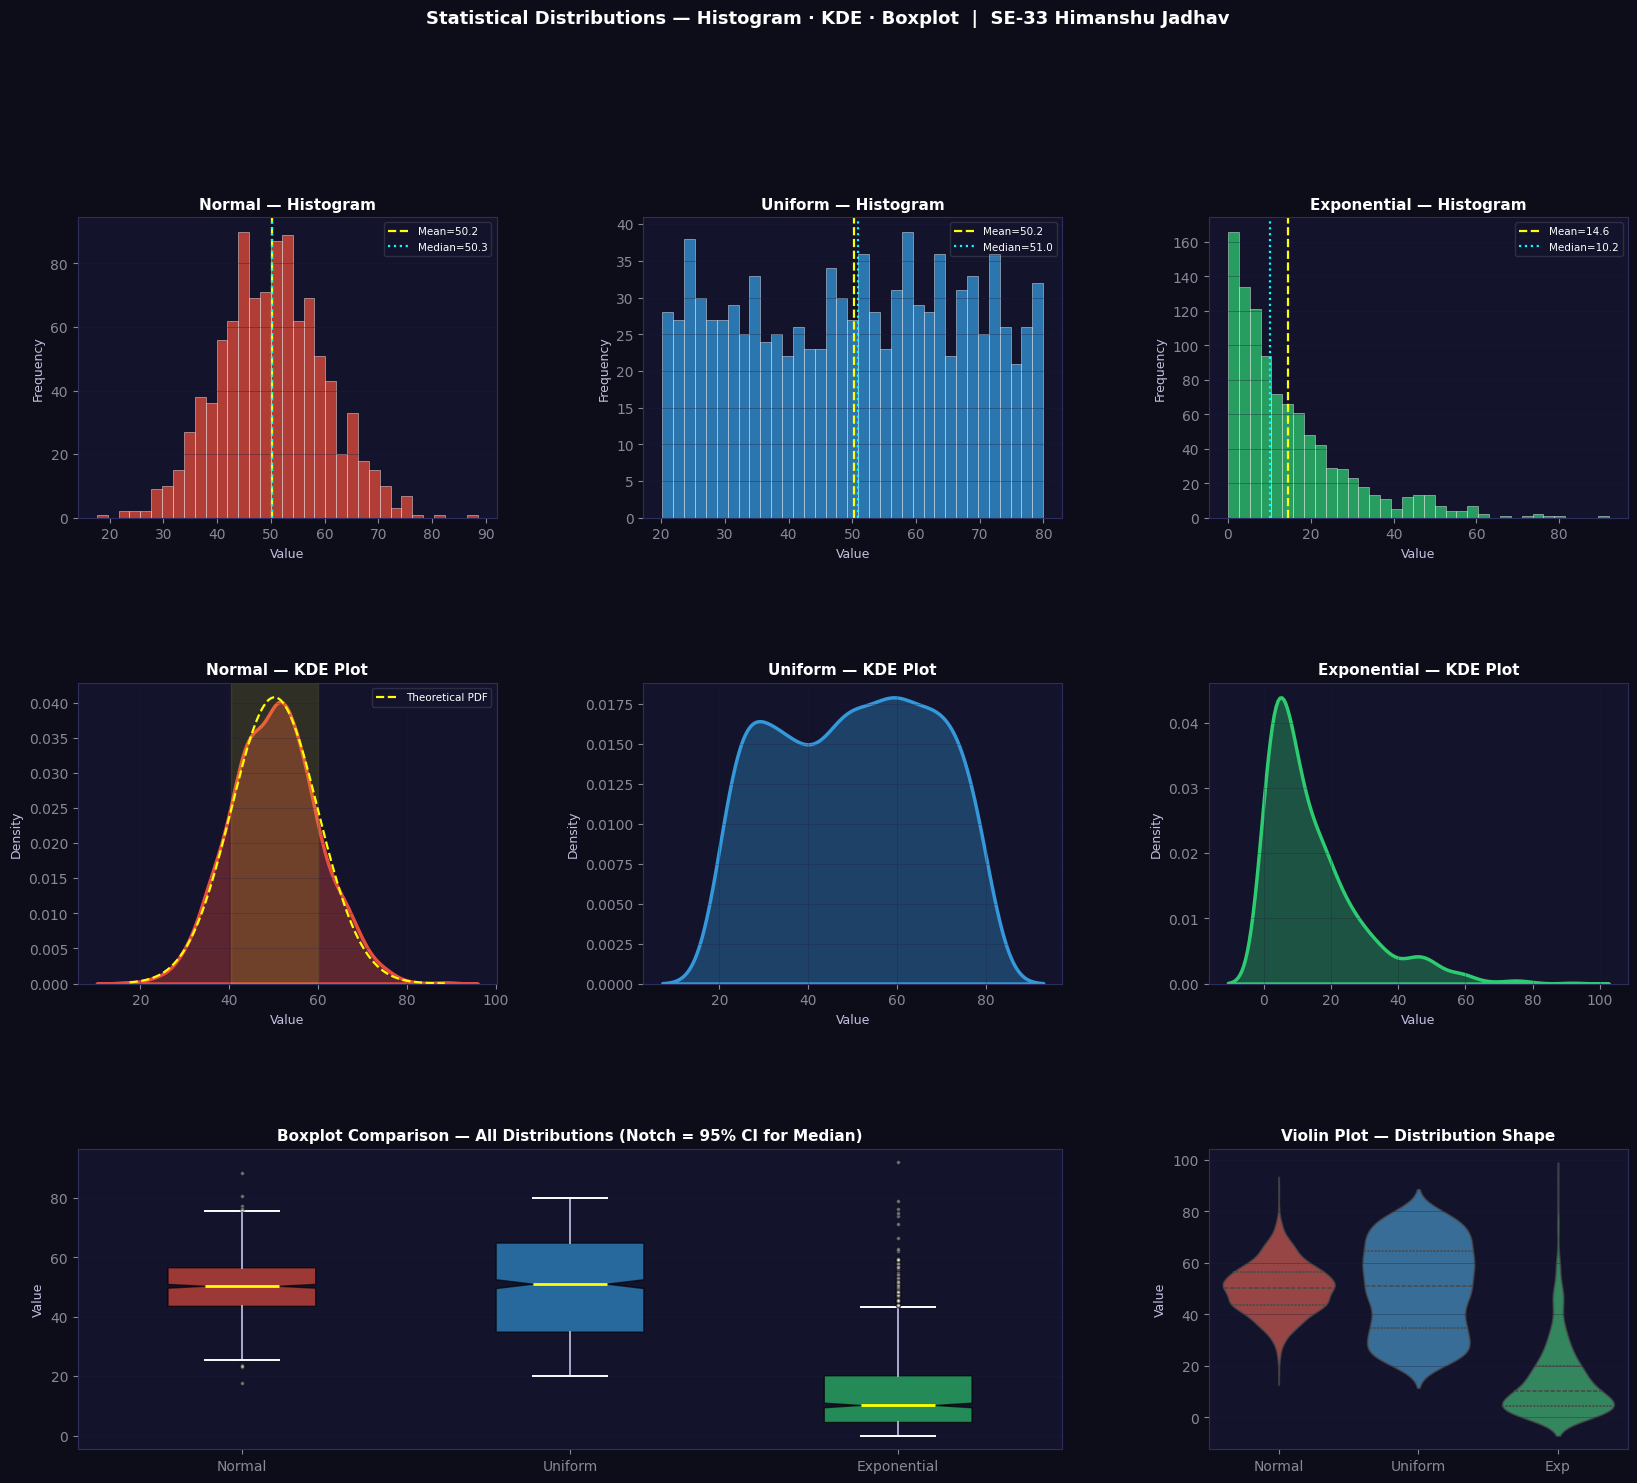

Visualization saved...


In [5]:
datasets    = [normal_data,  uniform_data,  exp_data]
dist_labels = ['Normal',     'Uniform',     'Exponential']
pal         = ['#e74c3c',    '#3498db',     '#2ecc71']

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# Row 0: Histograms
for col, (data, label, color) in enumerate(zip(datasets, dist_labels, pal)):
    ax = fig.add_subplot(gs[0, col])
    ax.hist(data, bins=35, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)

    # Mark mean and median as vertical lines
    ax.axvline(np.mean(data),   color='yellow', linestyle='--', lw=1.6, label=f'Mean={np.mean(data):.1f}')
    ax.axvline(np.median(data), color='cyan',   linestyle=':',  lw=1.6, label=f'Median={np.median(data):.1f}')

    ax.set_title(f'{label} — Histogram', fontsize=11, fontweight='bold', color='white')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=7.5, framealpha=0.15, labelcolor='white')
    ax.grid(True, axis='y', alpha=0.4)

# Row 1: KDE Plots 
for col, (data, label, color) in enumerate(zip(datasets, dist_labels, pal)):
    ax = fig.add_subplot(gs[1, col])

    # Kernel Density Estimate
    sns.kdeplot(data, ax=ax, color=color, linewidth=2.5, fill=True, alpha=0.35)

    # Overlay theoretical curve for normal distribution
    x_range = np.linspace(data.min(), data.max(), 300)
    if label == 'Normal':
        mu, sigma = np.mean(data), np.std(data)
        ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
                'yellow', linestyle='--', lw=1.6, label='Theoretical PDF')
        ax.legend(fontsize=7.5, framealpha=0.15, labelcolor='white')

    # Shade ±1σ region for Normal
    if label == 'Normal':
        ax.axvspan(mu - sigma, mu + sigma, alpha=0.12, color='yellow', label='±1σ')

    ax.set_title(f'{label} — KDE Plot', fontsize=11, fontweight='bold', color='white')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.grid(True, alpha=0.3)

# Row 2: Boxplots (combined + individual) 
# Combined boxplot — all three on one axis
ax_box = fig.add_subplot(gs[2, 0:2])
bp = ax_box.boxplot(
    datasets,
    labels       = dist_labels,
    patch_artist = True,
    notch        = True,          # notched = 95% CI for median
    widths       = 0.45,
    medianprops  = dict(color='yellow', linewidth=2),
    whiskerprops = dict(color='#aaaacc', linewidth=1.4),
    capprops     = dict(color='white',  linewidth=1.4),
    flierprops   = dict(marker='o', markerfacecolor='white', markersize=3, alpha=0.4)
)
for patch, color in zip(bp['boxes'], pal):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

ax_box.set_title('Boxplot Comparison — All Distributions (Notch = 95% CI for Median)',
                 fontsize=11, fontweight='bold', color='white')
ax_box.set_ylabel('Value', fontsize=9)
ax_box.grid(True, axis='y', alpha=0.4)

# Violin + strip — rightmost panel for depth
ax_vio = fig.add_subplot(gs[2, 2])
df_melt = pd.DataFrame({'Normal': normal_data, 'Uniform': uniform_data, 'Exp': exp_data})
df_long = df_melt.melt(var_name='Distribution', value_name='Value')

sns.violinplot(data=df_long, x='Distribution', y='Value', ax=ax_vio,
               palette={'Normal': '#e74c3c', 'Uniform': '#3498db', 'Exp': '#2ecc71'},
               inner='quartile', alpha=0.7)
ax_vio.set_title('Violin Plot — Distribution Shape', fontsize=11, fontweight='bold', color='white')
ax_vio.set_xlabel('')
ax_vio.set_ylabel('Value', fontsize=9)
ax_vio.grid(True, axis='y', alpha=0.4)

fig.suptitle('Statistical Distributions — Histogram · KDE · Boxplot  |  SE-33 Himanshu Jadhav',
             fontsize=13, fontweight='bold', color='white', y=1.01)

plt.savefig('stats_viz.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("Visualization saved...")

## Part 4: Hypothesis Testing - Two-Sample t-Test

In [6]:
group_A = np.random.normal(loc=72, scale=8, size=80)
group_B = np.random.normal(loc=76, scale=9, size=80)

print(f"Group A - Mean: {group_A.mean():.3f}, Std: {group_A.std():.3f}")
print(f"Group B - Mean: {group_B.mean():.3f}, Std: {group_B.std():.3f}")


Group A - Mean: 72.021, Std: 7.295
Group B - Mean: 78.279, Std: 8.710


In [7]:
lev_stat, lev_p = stats.levene(group_A, group_B)
equal_var = lev_p > 0.05

print(f"Levene's Test: stat={lev_stat:.4f}, p={lev_p:.4f}")
print(f"Equal Variance Assumed: {equal_var} -> using {'Student' if equal_var else "Welch"}'s t-test")

Levene's Test: stat=0.7418, p=0.3904
Equal Variance Assumed: True -> using Student's t-test


In [8]:
t_stat, p_value = stats.ttest_ind(group_A, group_B, equal_var=equal_var)
alpha           = 0.05

print("\n" + "=" * 50)
print(" Two-Sample t-Test Results")
print("=" * 50)
print(f"  H0 : μ_A = μ_B  (no significant difference)")
print(f"  H1 : μ_A != μ_B  (significant difference exists)")
print(f"  α  = {alpha}")
print("-" * 50)
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.6f}")
print("-" * 50)
if p_value < alpha:
    print(f"    REJECT H0 - p-{p_value:.4f} < α={alpha}")
    print(f"    Significant difference between Group A & B")
else:
    print(f"    FAIL to reject H0 - p={p_value:.4f} >= α={alpha}")
    print(f"    No significant difference between Group A & B")
print("=" * 50)


 Two-Sample t-Test Results
  H0 : μ_A = μ_B  (no significant difference)
  H1 : μ_A != μ_B  (significant difference exists)
  α  = 0.05
--------------------------------------------------
  t-statistic : -4.8962
  p-value     : 0.000002
--------------------------------------------------
    REJECT H0 - p-0.0000 < α=0.05
    Significant difference between Group A & B


In [9]:
for label, g in [('Group A', group_A), ('Group B', group_B)]:
    w_stat, sw_p = stats.shapiro(g[:50])
    print(f"Shapiro-Wilk {label}: W={w_stat:.4f}, p={sw_p:.4f} -> "
          f"{'Normal' if sw_p > 0.05 else 'Non-normal'}")

Shapiro-Wilk Group A: W=0.9827, p=0.6689 -> Normal
Shapiro-Wilk Group B: W=0.9802, p=0.5618 -> Normal


## Part 5: Confidence Intervals (95%)

In [10]:
def confidence_interval_95(data, label):
    n      = len(data)
    mean   = np.mean(data)
    se     = stats.sem(data)
    ci     = stats.t.interval(0.95, df=n-1,
                            loc=mean, scale=se)
    margin = ci[1] - mean
    print(f"  {label:<12} -> Mean={mean:6.3f}  |  95% CI: [{ci[0]:.3f}, {ci[1]:.3f}] "
          f"|  Margin of Error: ±{margin:.3f}")
    return ci

print("=" * 85)
print(" 95% Confidence Intervals")
print("=" * 85)
ci_normal  = confidence_interval_95(normal_data,  'Normal')
ci_uniform = confidence_interval_95(uniform_data, 'Uniform')
ci_exp     = confidence_interval_95(exp_data,     'Exponential')
ci_A       = confidence_interval_95(group_A,      'Group A')
ci_B       = confidence_interval_95(group_B,      'Group B')
print("=" * 85)



 95% Confidence Intervals
  Normal       -> Mean=50.193  |  95% CI: [49.586, 50.801] |  Margin of Error: ±0.608
  Uniform      -> Mean=50.219  |  95% CI: [49.145, 51.293] |  Margin of Error: ±1.074
  Exponential  -> Mean=14.599  |  95% CI: [13.719, 15.479] |  Margin of Error: ±0.880
  Group A      -> Mean=72.021  |  95% CI: [70.387, 73.654] |  Margin of Error: ±1.634
  Group B      -> Mean=78.279  |  95% CI: [76.329, 80.230] |  Margin of Error: ±1.951


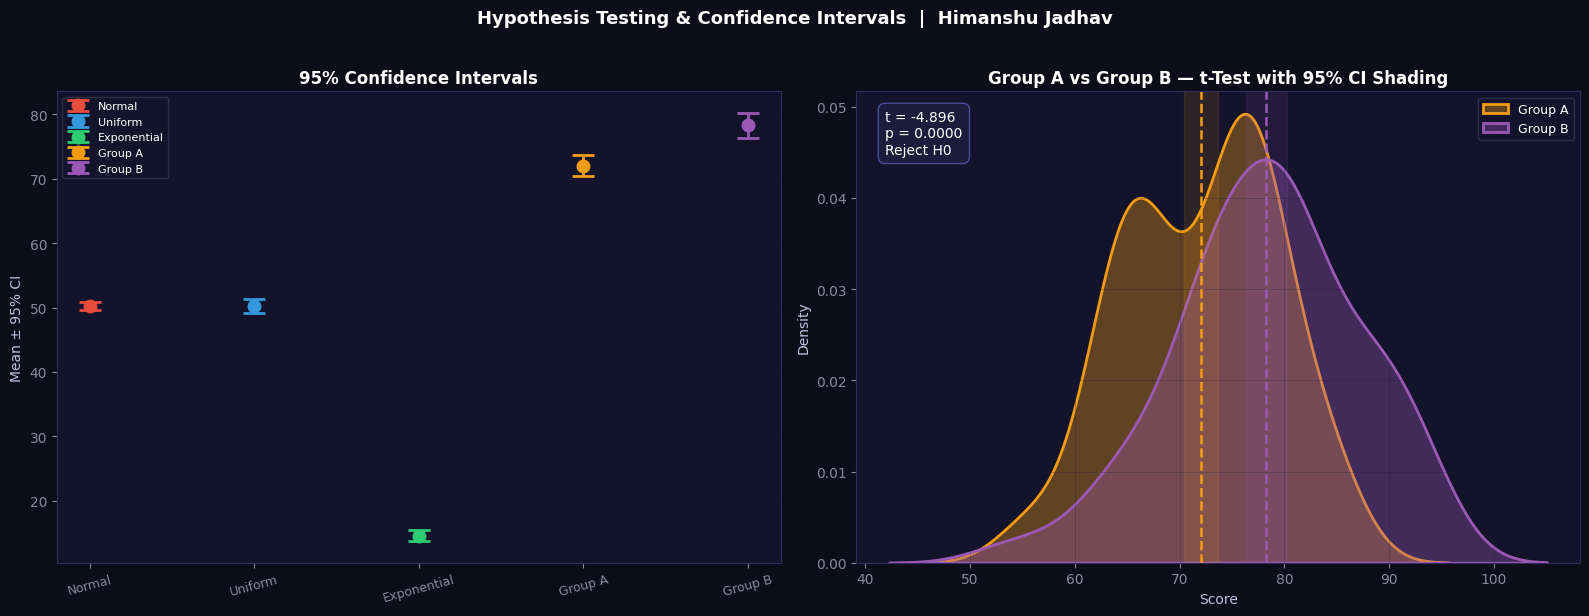

Plot saved...


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d1a')

ax = axes[0]
ax.set_facecolor('#13132b')

series    = [normal_data, uniform_data, exp_data, group_A, group_B]
labels    = ['Normal', 'Uniform', 'Exponential', 'Group A', 'Group B']
colors_ci = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
ci_bounds = [ci_normal, ci_uniform, ci_exp, ci_A, ci_B]
means     = [np.mean(d) for d in series]

for i, (m, ci, lbl, col) in enumerate(zip(means, ci_bounds, labels, colors_ci)):
    err = m - ci[0]   # margin of error
    ax.errorbar(i, m, yerr=err, fmt='o', color=col, capsize=8, capthick=2,
                elinewidth=2, markersize=9, label=lbl)

ax.set_xticks(range(5))
ax.set_xticklabels(labels, rotation=15, fontsize=9)
ax.set_title('95% Confidence Intervals', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean ± 95% CI', fontsize=10)
ax.grid(True, axis='y', alpha=0.35)
ax.legend(fontsize=8, framealpha=0.15, labelcolor='white')

ax2 = axes[1]
ax2.set_facecolor('#13132b')

sns.kdeplot(group_A, ax=ax2, color='#f39c12', fill=True, alpha=0.35, linewidth=2, label='Group A')
sns.kdeplot(group_B, ax=ax2, color='#9b59b6', fill=True, alpha=0.35, linewidth=2, label='Group B')

ax2.axvspan(ci_A[0], ci_A[1], alpha=0.12, color='#f39c12')
ax2.axvspan(ci_B[0], ci_B[1], alpha=0.12, color='#9b59b6')

ax2.axvline(np.mean(group_A), color='#f39c12', lw=1.8, ls='--')
ax2.axvline(np.mean(group_B), color='#9b59b6', lw=1.8, ls='--')

verdict = f"t = {t_stat:.3f}\np = {p_value:.4f}\n{'Reject H0' if p_value < 0.05 else 'Fail to Reject H0'}"
ax2.text(0.04, 0.96, verdict, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', color='white',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1e1e40', edgecolor='#5555aa', alpha=0.85))

ax2.set_title('Group A vs Group B — t-Test with 95% CI Shading', fontsize=12, fontweight='bold')
ax2.set_xlabel('Score', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.15, labelcolor='white')
ax2.grid(True, alpha=0.3)

fig.suptitle('Hypothesis Testing & Confidence Intervals  |  Himanshu Jadhav',
             fontsize=13, fontweight='bold', color='white', y=1.02)

plt.tight_layout()
plt.savefig('stats_ci_ttest.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("Plot saved...")